Matplotlib is building the font cache; this may take a moment.



PANDAS ANALYZER & DATA VISUALIZER

Sample dataset loaded successfully!
Shape: (9, 6)

DATASET PREVIEW
      Date Product Region  Sales  Profit  Quantity
0  2024-01  Laptop  North  15000    3000        50
1  2024-01   Phone  South  12000    2400       120
2  2024-01  Tablet   East   8000    1600        80
3  2024-02  Laptop  North  18000    3600        60
4  2024-02   Phone  South  14000    2800       140
5  2024-02  Tablet   West   9000    1800        90
6  2024-03  Laptop   East  20000    4000        70
7  2024-03   Phone  North  16000    3200       160
8  2024-03  Tablet  South  10000    2000       100



DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      9 non-null      object
 1   Product   9 non-null      object
 2   Region    9 non-null      object
 3   Sales     9 non-null      int64 
 4   Profit    9 non-null      int64

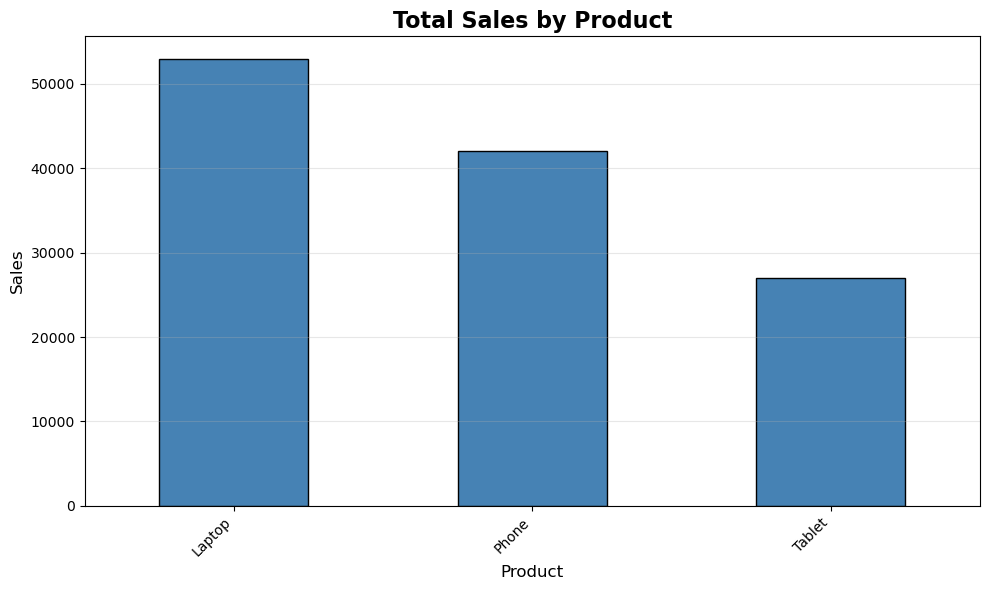

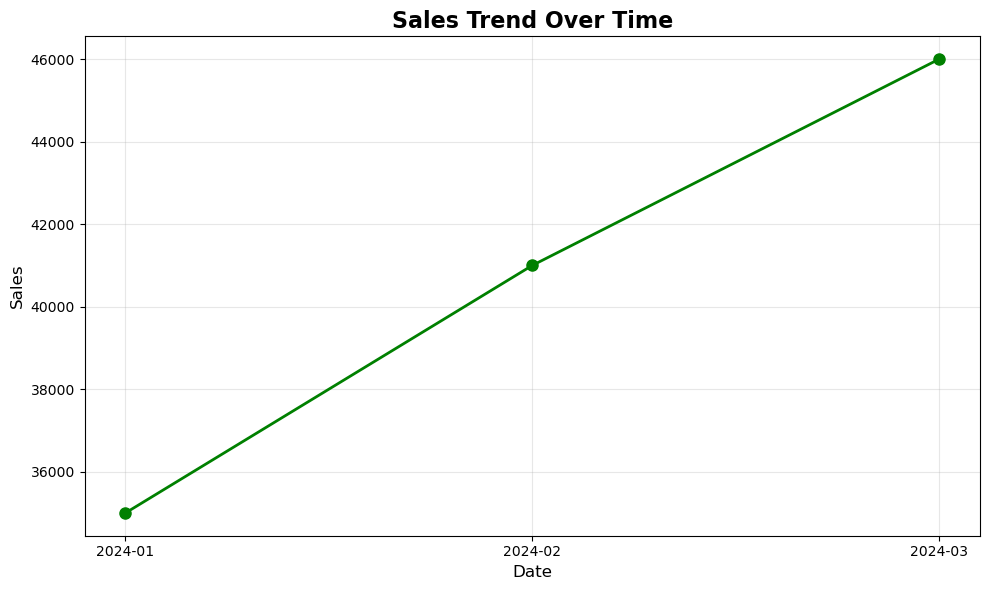

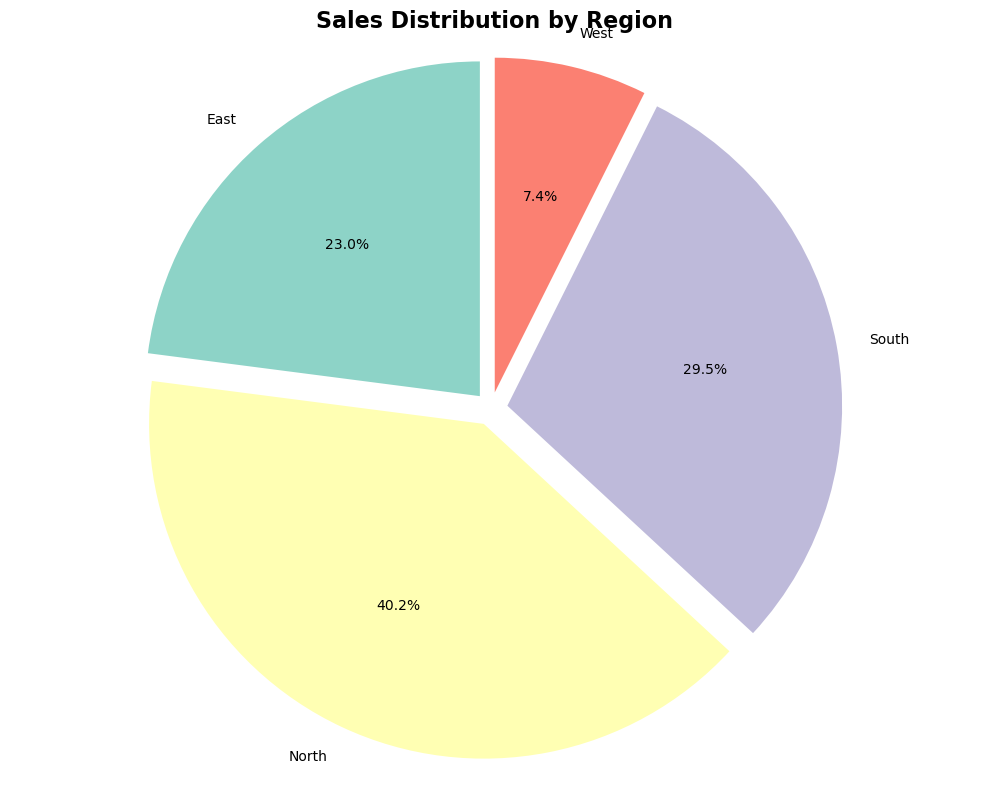

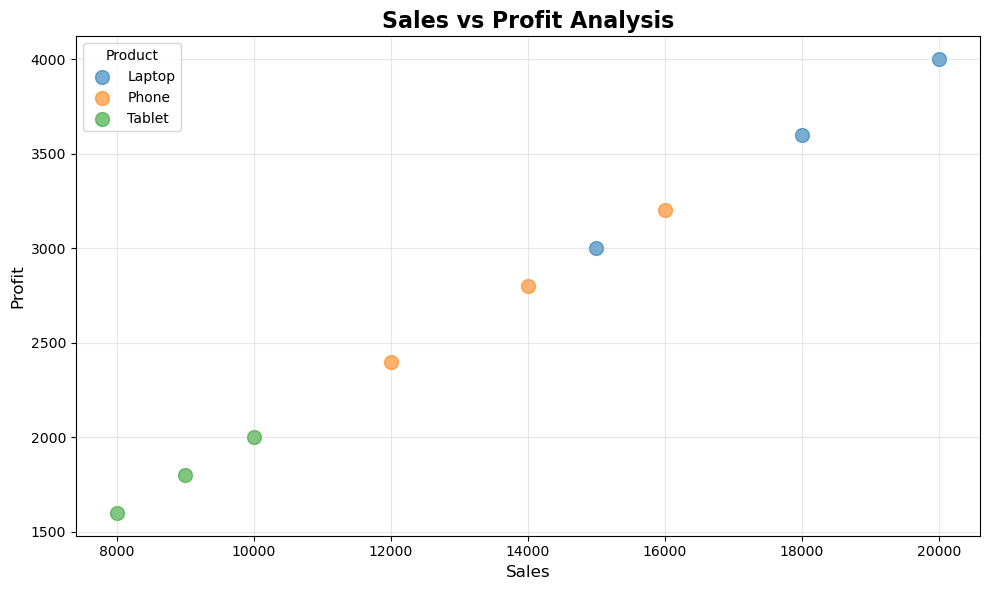

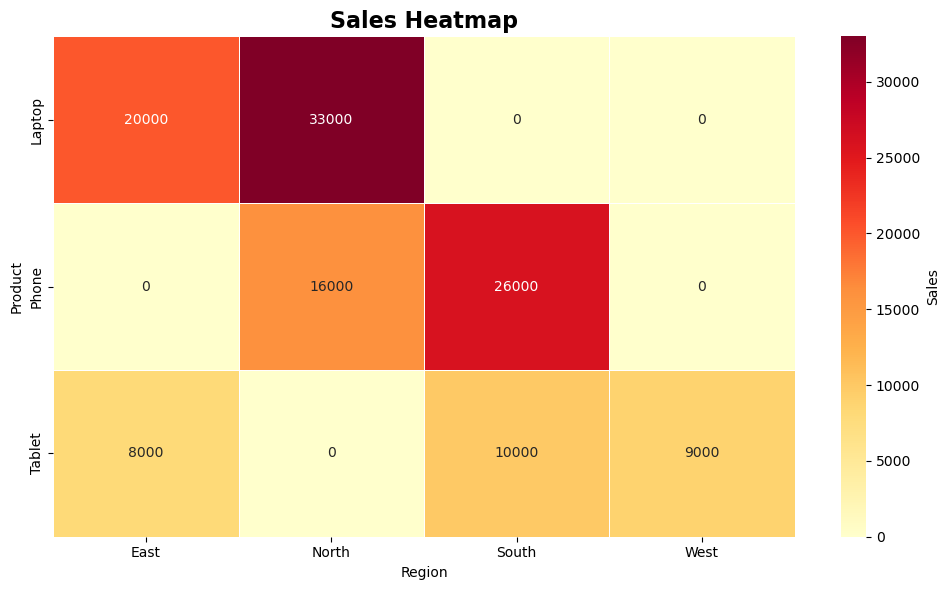


Analysis completed!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

class SalesAnalyzer:
    """
    A comprehensive Sales Data Analysis class using Pandas for data manipulation
    and analysis with built-in visualization capabilities.
    """
    
    def __init__(self, data=None):
        """Initialize the SalesAnalyzer with optional data."""
        self.data = data
        self.filtered_data = None
        self.stats = {}
        
    def load_sample_data(self):
        """Load a sample sales dataset for demonstration."""
        sample_data = {
            'Date': ['2024-01', '2024-01', '2024-01', '2024-02', '2024-02', 
                    '2024-02', '2024-03', '2024-03', '2024-03'],
            'Product': ['Laptop', 'Phone', 'Tablet', 'Laptop', 'Phone', 
                       'Tablet', 'Laptop', 'Phone', 'Tablet'],
            'Region': ['North', 'South', 'East', 'North', 'South', 
                      'West', 'East', 'North', 'South'],
            'Sales': [15000, 12000, 8000, 18000, 14000, 9000, 20000, 16000, 10000],
            'Profit': [3000, 2400, 1600, 3600, 2800, 1800, 4000, 3200, 2000],
            'Quantity': [50, 120, 80, 60, 140, 90, 70, 160, 100]
        }
        self.data = pd.DataFrame(sample_data)
        self.filtered_data = self.data.copy()
        print("Sample dataset loaded successfully!")
        print(f"Shape: {self.data.shape}")
        return self.data
    
    def load_csv(self, filepath):
        """Load data from a CSV file."""
        try:
            self.data = pd.read_csv(filepath)
            self.filtered_data = self.data.copy()
            print(f"Data loaded successfully from {filepath}")
            print(f"Shape: {self.data.shape}")
            return self.data
        except Exception as e:
            print(f"Error loading data: {e}")
            return None
    
    def display_data(self, n=10):
        """Display first n rows of the dataset."""
        if self.data is not None:
            print("\n" + "="*80)
            print("DATASET PREVIEW")
            print("="*80)
            print(self.data.head(n))
            print("\n")
        else:
            print("No data loaded. Please load data first.")
    
    def get_info(self):
        """Display information about the dataset."""
        if self.data is not None:
            print("\n" + "="*80)
            print("DATASET INFORMATION")
            print("="*80)
            print(self.data.info())
            print(f"\nMissing values:\n{self.data.isnull().sum()}")
            print("\n")
        else:
            print("No data loaded. Please load data first.")
    
    def filter_data(self, column, value):
        """Filter data by specific column value."""
        if self.data is not None:
            self.filtered_data = self.data[self.data[column] == value]
            print(f"Data filtered: {column} = {value}")
            print(f"Filtered shape: {self.filtered_data.shape}")
            return self.filtered_data
        else:
            print("No data loaded. Please load data first.")
            return None
    
    def reset_filter(self):
        """Reset filter to show all data."""
        if self.data is not None:
            self.filtered_data = self.data.copy()
            print("Filter reset. Showing all data.")
        
    def calculate_statistics(self, columns=None):
        """Calculate comprehensive statistics for numeric columns."""
        if self.filtered_data is not None:
            if columns is None:
                columns = self.filtered_data.select_dtypes(include=[np.number]).columns
            
            print("\n" + "="*80)
            print("STATISTICAL ANALYSIS")
            print("="*80)
            
            for col in columns:
                if col in self.filtered_data.columns:
                    data_col = self.filtered_data[col]
                    stats = {
                        'count': len(data_col),
                        'mean': data_col.mean(),
                        'median': data_col.median(),
                        'std': data_col.std(),
                        'min': data_col.min(),
                        'max': data_col.max(),
                        'sum': data_col.sum(),
                        'q25': data_col.quantile(0.25),
                        'q75': data_col.quantile(0.75)
                    }
                    self.stats[col] = stats
                    
                    print(f"\n{col}:")
                    print(f"  Count:    {stats['count']}")
                    print(f"  Mean:     {stats['mean']:.2f}")
                    print(f"  Median:   {stats['median']:.2f}")
                    print(f"  Std Dev:  {stats['std']:.2f}")
                    print(f"  Min:      {stats['min']:.2f}")
                    print(f"  Max:      {stats['max']:.2f}")
                    print(f"  Sum:      {stats['sum']:.2f}")
                    print(f"  Q25:      {stats['q25']:.2f}")
                    print(f"  Q75:      {stats['q75']:.2f}")
            
            print("\n")
            return self.stats
        else:
            print("No data available for analysis.")
            return None
    
    def aggregate_by(self, group_col, agg_col, func='sum'):
        """Aggregate data by a grouping column."""
        if self.filtered_data is not None:
            if func == 'sum':
                result = self.filtered_data.groupby(group_col)[agg_col].sum()
            elif func == 'mean':
                result = self.filtered_data.groupby(group_col)[agg_col].mean()
            elif func == 'count':
                result = self.filtered_data.groupby(group_col)[agg_col].count()
            elif func == 'max':
                result = self.filtered_data.groupby(group_col)[agg_col].max()
            elif func == 'min':
                result = self.filtered_data.groupby(group_col)[agg_col].min()
            else:
                result = self.filtered_data.groupby(group_col)[agg_col].sum()
            
            print(f"\nAggregation: {func}({agg_col}) by {group_col}")
            print("-" * 50)
            print(result)
            print("\n")
            return result
        else:
            print("No data available for aggregation.")
            return None
    
    def pivot_table(self, index, columns, values, aggfunc='sum'):
        """Create a pivot table."""
        if self.filtered_data is not None:
            pivot = pd.pivot_table(
                self.filtered_data,
                index=index,
                columns=columns,
                values=values,
                aggfunc=aggfunc,
                fill_value=0
            )
            print(f"\nPivot Table: {values} by {index} and {columns}")
            print("="*80)
            print(pivot)
            print("\n")
            return pivot
        else:
            print("No data available for pivot table.")
            return None
    
    def visualize_bar_chart(self, group_col, value_col, title=None):
        """Create a bar chart visualization."""
        if self.filtered_data is not None:
            agg_data = self.filtered_data.groupby(group_col)[value_col].sum()
            
            plt.figure(figsize=(10, 6))
            agg_data.plot(kind='bar', color='steelblue', edgecolor='black')
            plt.title(title or f'{value_col} by {group_col}', fontsize=16, fontweight='bold')
            plt.xlabel(group_col, fontsize=12)
            plt.ylabel(value_col, fontsize=12)
            plt.xticks(rotation=45, ha='right')
            plt.grid(axis='y', alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            print("No data available for visualization.")
    
    def visualize_line_chart(self, x_col, y_col, title=None):
        """Create a line chart visualization."""
        if self.filtered_data is not None:
            agg_data = self.filtered_data.groupby(x_col)[y_col].sum()
            
            plt.figure(figsize=(10, 6))
            plt.plot(agg_data.index, agg_data.values, marker='o', 
                    linewidth=2, markersize=8, color='green')
            plt.title(title or f'{y_col} Trend over {x_col}', fontsize=16, fontweight='bold')
            plt.xlabel(x_col, fontsize=12)
            plt.ylabel(y_col, fontsize=12)
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            print("No data available for visualization.")
    
    def visualize_pie_chart(self, group_col, value_col, title=None):
        """Create a pie chart visualization."""
        if self.filtered_data is not None:
            agg_data = self.filtered_data.groupby(group_col)[value_col].sum()
            
            plt.figure(figsize=(10, 8))
            colors = plt.cm.Set3(range(len(agg_data)))
            plt.pie(agg_data.values, labels=agg_data.index, autopct='%1.1f%%',
                   startangle=90, colors=colors, explode=[0.05] * len(agg_data))
            plt.title(title or f'{value_col} Distribution by {group_col}', 
                     fontsize=16, fontweight='bold')
            plt.axis('equal')
            plt.tight_layout()
            plt.show()
        else:
            print("No data available for visualization.")
    
    def visualize_scatter(self, x_col, y_col, hue=None, title=None):
        """Create a scatter plot visualization."""
        if self.filtered_data is not None:
            plt.figure(figsize=(10, 6))
            if hue:
                for category in self.filtered_data[hue].unique():
                    data = self.filtered_data[self.filtered_data[hue] == category]
                    plt.scatter(data[x_col], data[y_col], label=category, alpha=0.6, s=100)
                plt.legend(title=hue)
            else:
                plt.scatter(self.filtered_data[x_col], self.filtered_data[y_col], 
                          alpha=0.6, s=100, color='purple')
            
            plt.title(title or f'{y_col} vs {x_col}', fontsize=16, fontweight='bold')
            plt.xlabel(x_col, fontsize=12)
            plt.ylabel(y_col, fontsize=12)
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            print("No data available for visualization.")
    
    def visualize_heatmap(self, index, columns, values, title=None):
        """Create a heatmap visualization."""
        if self.filtered_data is not None:
            pivot = pd.pivot_table(
                self.filtered_data,
                index=index,
                columns=columns,
                values=values,
                aggfunc='sum',
                fill_value=0
            )
            
            plt.figure(figsize=(10, 6))
            sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', 
                       cbar_kws={'label': values}, linewidths=0.5)
            plt.title(title or f'{values} Heatmap: {index} vs {columns}', 
                     fontsize=16, fontweight='bold')
            plt.tight_layout()
            plt.show()
        else:
            print("No data available for visualization.")
    
    def generate_report(self):
        """Generate a comprehensive analysis report."""
        if self.filtered_data is not None:
            print("\n" + "="*80)
            print("COMPREHENSIVE SALES ANALYSIS REPORT")
            print("="*80)
            print(f"Report Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
            print(f"Total Records: {len(self.filtered_data)}")
            print("\n")
            
            # Summary statistics
            self.calculate_statistics()
            
            # Group by Product
            print("Sales by Product:")
            print("-" * 50)
            print(self.aggregate_by('Product', 'Sales', 'sum'))
            
            # Group by Region
            print("Sales by Region:")
            print("-" * 50)
            print(self.aggregate_by('Region', 'Sales', 'sum'))
            
            # Profit margins
            if 'Sales' in self.filtered_data.columns and 'Profit' in self.filtered_data.columns:
                self.filtered_data['Profit_Margin'] = (
                    self.filtered_data['Profit'] / self.filtered_data['Sales'] * 100
                )
                print("Average Profit Margin by Product:")
                print("-" * 50)
                print(self.aggregate_by('Product', 'Profit_Margin', 'mean'))
            
            print("\n" + "="*80)
            print("END OF REPORT")
            print("="*80 + "\n")
        else:
            print("No data available for report generation.")


# Example Usage
def main():
    """Main function demonstrating all features."""
    
    print("\n" + "="*80)
    print("PANDAS ANALYZER & DATA VISUALIZER")
    print("="*80 + "\n")
    
    # Initialize analyzer
    analyzer = SalesAnalyzer()
    
    # Load sample data
    analyzer.load_sample_data()
    
    # Display data
    analyzer.display_data(10)
    
    # Get dataset info
    analyzer.get_info()
    
    # Calculate statistics
    analyzer.calculate_statistics()
    
    # Aggregations
    analyzer.aggregate_by('Product', 'Sales', 'sum')
    analyzer.aggregate_by('Region', 'Profit', 'mean')
    
    # Create pivot table
    analyzer.pivot_table('Product', 'Region', 'Sales', 'sum')
    
    # Filter data
    analyzer.filter_data('Product', 'Laptop')
    analyzer.display_data(5)
    analyzer.reset_filter()
    
    # Generate comprehensive report
    analyzer.generate_report()
    
    # Visualizations
    print("\nGenerating visualizations...")
    print("(Close each plot window to see the next one)")
    
    analyzer.visualize_bar_chart('Product', 'Sales', 'Total Sales by Product')
    analyzer.visualize_line_chart('Date', 'Sales', 'Sales Trend Over Time')
    analyzer.visualize_pie_chart('Region', 'Sales', 'Sales Distribution by Region')
    analyzer.visualize_scatter('Sales', 'Profit', 'Product', 'Sales vs Profit Analysis')
    analyzer.visualize_heatmap('Product', 'Region', 'Sales', 'Sales Heatmap')
    
    print("\nAnalysis completed!")

if __name__ == "__main__":
    main()